In [ ]:
# 이미지 숫자 판별 예제 - CNN X, 일반 Dense layer를 이용한 방법

In [ ]:
# 데이터 생성
import tensorflow as tf
# tf.keras.datasets.mnist.load_data()
# => 데이터 로드
# => 독립, 종속 분리
# => 훈련, 테스트 분리

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# 독립, 종속 분리(최대값 255)
X_train = X_train / 255.0

# 2차원 행렬 -> 1차원으로 변형 (60000, 28, 28) => (60000, 784)
X_train = X_train.reshape(-1, 784)

X_test = X_test.reshape(-1, 784) / 255.0

In [ ]:
# 학습, 테스트 분리

In [ ]:
# 정규화

In [4]:
# 모델 설계
model = tf.keras.Sequential([
	tf.keras.Input((784,)),
	tf.keras.layers.Dense(256, activation='relu'),
	tf.keras.layers.Dense(128, activation='relu'),
	tf.keras.layers.Dense(64, activation='relu'),
	tf.keras.layers.Dense(10, activation='softmax'),
])

In [6]:
# 모델 설정
model.compile(optimizer='adam', 
							loss='sparse_categorical_crossentropy',
							metrics=['accuracy']
							)

In [9]:
import tensorflow as data
dataset = data.data.Dataset.from_tensor_slices((X_train, y_train))
# 데이터를 묶고, 모델이 학습하는 동안 다음 데이터를 미리 준비
dataset = dataset.batch(128).prefetch(data.data.AUTOTUNE)
# 학습
history = model.fit(
	dataset,
	epochs = 50,
	verbose = 1
	)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9146 - loss: 0.2953
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9656 - loss: 0.1131
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9777 - loss: 0.0738
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9843 - loss: 0.0517
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9883 - loss: 0.0388
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0295
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9916 - loss: 0.0256
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0242
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9942 - loss: 0.0182
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9944 - loss: 0.0160
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9942 - loss: 0.0173
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [11]:
# 평가
_, test_acc = model.evaluate(X_test,y_test)
print(f'정확도 : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.1444
정확도 : 0.9775999784469604


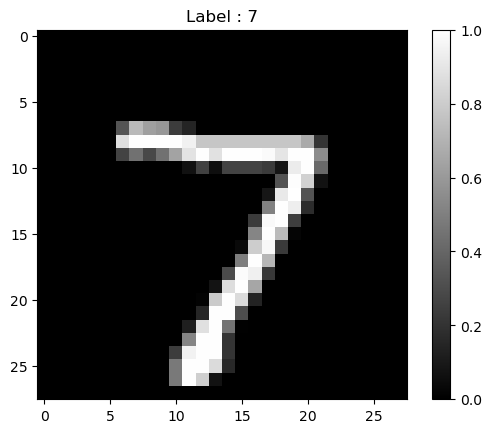

In [13]:
# 시각화 (판별한 이미지를 보여줌), 테스트 이미지 중 0번지에 있는 이미지
import matplotlib.pyplot as plt
plt.imshow(X_test[0].reshape(28,-1), cmap='gray')
plt.title(f'Label : {y_test[0]}')
plt.colorbar()
plt.show()


In [15]:
# 예측
import numpy as np
# print(X_test[0].reshape(784))
predict = model.predict(np.array([X_test[0].reshape(784)]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {y_test[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
예측 숫자 : 7
실제 숫자 : 7


In [18]:
# 이미지 불러오기
import cv2
img = cv2.imread('../data/img/test_6.png', cv2.IMREAD_GRAYSCALE)
# 전처리 하기
resize_img = cv2.resize(img, (28, 28)) # 테스트 이미지가 28 x 28이 아니기 때문에 크기 변경
# 이미지를 1차 배열로 변환
img_data = resize_img.flatten()
# 정규화
img_data = img_data / 255.0

predict = model.predict(np.array([img_data]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {6}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
예측 숫자 : 2
실제 숫자 : 6


In [19]:
# 이미지 불러오기
import cv2
real_num = 3
img = cv2.imread('../data/img/test_3.png', cv2.IMREAD_GRAYSCALE)
# 전처리 하기
resize_img = cv2.resize(img, (28, 28)) # 테스트 이미지가 28 x 28이 아니기 때문에 크기 변경
# 이미지를 1차 배열로 변환
img_data = resize_img.flatten()
# 정규화
img_data = img_data / 255.0

predict = model.predict(np.array([img_data]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {real_num}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
예측 숫자 : 3
실제 숫자 : 3
